# Error Analysis & Model Comparison
Produces comparison tables, error analysis, and per-class heatmaps.

**Note**: All the results will be saved and read on/from the local Google Drive in `StanceProject` directory.

In [ ]:
!pip install -q pandas matplotlib seaborn scikit-learn transformers accelerate

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import os
PROJECT = '/content/drive/MyDrive/StanceProject'

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Drive mounted. Project: /content/drive/MyDrive/StanceProject


In [ ]:
# load all libraries
import pandas as pd
import json
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from sklearn.metrics import f1_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
import torch, glob, re
from torch.utils.data import Dataset, DataLoader
from transformers import AutoTokenizer, AutoModelForSequenceClassification
from sklearn.model_selection import train_test_split
warnings.filterwarnings('ignore')
plt.rcParams['figure.dpi'] = 120

Ready.


## Load baseline results

In [ ]:
bl_path = f'{PROJECT}/results/baseline_results.csv'
baseline = pd.read_csv(bl_path)
print(baseline.to_string(index=False))

Baseline results:
                 dataset model  macro_f1
        covid-vax-stance    LR    0.3955
        covid-vax-stance   SVM    0.4931
        TweetEval-stance    LR    0.3719
        TweetEval-stance   SVM    0.5110
CVS→TweetEval (transfer)    LR    0.1820
CVS→TweetEval (transfer)   SVM    0.2293
TweetEval→CVS (transfer)    LR    0.1196
TweetEval→CVS (transfer)   SVM    0.1929


## Load BERTweet predictions

In [ ]:
bertweet_rows = []
for code, name in [('cvs','covid-vax-stance'), ('te','TweetEval-stance')]:
    path = f'{PROJECT}/predictions/bertweet_{code}_preds.csv'
    p = pd.read_csv(path)
    mf1 = f1_score(p['label_id'], p['pred_id'], average='macro')
    bertweet_rows.append({'dataset': name, 'model': 'BERTweet', 'macro_f1': round(mf1, 4)})
    print(f'BERTweet on {name}: macro-F1={mf1:.4f}')

bertweet_df = pd.DataFrame(bertweet_rows)

BERTweet on covid-vax-stance: macro-F1=0.6240
BERTweet on TweetEval-stance: macro-F1=0.6615


## Comparison table & bar chart

=== In-domain Macro-F1 ===
dataset   TweetEval-stance  covid-vax-stance
model                                       
BERTweet            0.6615            0.6240
LR                  0.3719            0.3955
SVM                 0.5110            0.4931


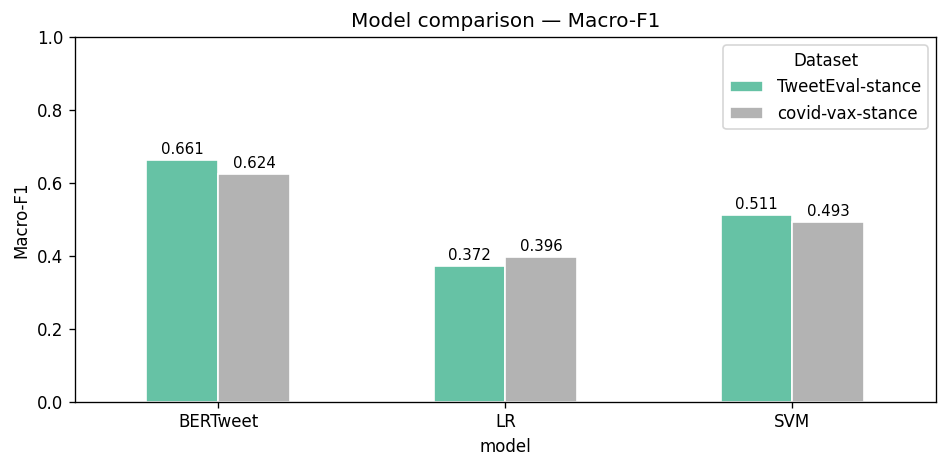

In [ ]:
in_domain = baseline[~baseline['dataset'].str.contains('transfer')]
all_results = pd.concat([in_domain, bertweet_df], ignore_index=True)
pivot = all_results.pivot_table(index='model', columns='dataset', values='macro_f1')

print(pivot.to_string())

fig, ax = plt.subplots(figsize=(8, 4))
pivot.plot(kind='bar', ax=ax, colormap='Set2', edgecolor='white')
ax.set_title('Model comparison — Macro-F1')
ax.set_ylabel('Macro-F1')
ax.set_ylim(0, 1.0)
ax.legend(title='Dataset')
ax.tick_params(axis='x', rotation=0)
for c in ax.containers:
    ax.bar_label(c, fmt='%.3f', padding=2, fontsize=9)
plt.tight_layout()
plt.savefig(f'{PROJECT}/plots/model_comparison.png', bbox_inches='tight')
plt.show()

## Cross-dataset transfer results

In [ ]:
transfer = baseline[baseline['dataset'].str.contains('transfer')]
print(transfer.to_string(index=False))

=== Cross-domain transfer ===
                 dataset model  macro_f1
CVS→TweetEval (transfer)    LR    0.1820
CVS→TweetEval (transfer)   SVM    0.2293
TweetEval→CVS (transfer)    LR    0.1196
TweetEval→CVS (transfer)   SVM    0.1929


## BERTweet cross-domain transfer
Load each saved model and run inference on the opposite dataset with no retraining.

In [ ]:
MODEL_NAME = 'vinai/bertweet-base'
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME, use_fast=False)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

CVS_TO_UNIFIED = {'ProVax': 'FAVOR', 'AntiVax': 'AGAINST', 'Neutral': 'NONE'}
TE_TO_UNIFIED = {'favor': 'FAVOR', 'against': 'AGAINST', 'none': 'NONE'}

def preprocess_tweet(text):
    text = re.sub(r'http\S+', 'HTTPURL', str(text))
    return re.sub(r'@\w+', '@USER', text).strip()

class TweetDataset(Dataset):
    def __init__(self, texts, tok, max_len=128):
        self.enc = tok(list(texts), truncation=True, padding=True, max_length=max_len, return_tensors='pt')
    def __len__(self): return self.enc['input_ids'].shape[0]
    def __getitem__(self, i): return {k: v[i] for k, v in self.enc.items()}

def bertweet_transfer(src_code, label_map, tgt_df):
    ckpts = sorted(glob.glob(f'{PROJECT}/models/bertweet_{src_code}/checkpoint-*'))
    model = AutoModelForSequenceClassification.from_pretrained(ckpts[-1]).to(device).eval()
    id2label = model.config.id2label

    loader = DataLoader(TweetDataset(tgt_df['text'].apply(preprocess_tweet), tokenizer), batch_size=64)
    preds = []
    with torch.no_grad():
        for batch in loader:
            batch = {k: v.to(device) for k, v in batch.items()}
            preds.extend(model(**batch).logits.argmax(-1).cpu().tolist())

    pred_unified = [label_map[id2label[p]] for p in preds]
    true_unified = tgt_df['label_unified'].tolist()
    f1 = f1_score(true_unified, pred_unified, average='macro')
    print(classification_report(true_unified, pred_unified, digits=3))
    return f1

# load data and reproduce test splits
cvs = pd.read_csv(f'{PROJECT}/data/processed/covid_vax_stance.csv')
te  = pd.read_csv(f'{PROJECT}/data/processed/tweeteval_stance.csv')

if 'split' in cvs.columns and cvs['split'].nunique() > 1:
    cvs_test = cvs[cvs['split'].isin(['test', 'validation'])].copy()
else:
    _, cvs_test = train_test_split(cvs, test_size=0.15, random_state=42, stratify=cvs['label'])

te_test = te[te['split'] == 'test'].copy()

bt_transfer_rows = []
f1 = bertweet_transfer('cvs', CVS_TO_UNIFIED, te_test)
if f1: bt_transfer_rows.append({'dataset': 'CVS model on TweetEval dataset', 'model': 'BERTweet', 'macro_f1': round(f1, 4)})
f1 = bertweet_transfer('te', TE_TO_UNIFIED, cvs_test)
if f1: bt_transfer_rows.append({'dataset': 'TweetEval model on CVS dataset', 'model': 'BERTweet', 'macro_f1': round(f1, 4)})

bt_transfer_df = pd.DataFrame(bt_transfer_rows)
print(bt_transfer_df.to_string(index=False))

config.json:   0%|          | 0.00/558 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/843k [00:00<?, ?B/s]

bpe.codes:   0%|          | 0.00/1.08M [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/2.91M [00:00<?, ?B/s]

[transformers] emoji is not installed, thus not converting emoticons or emojis into text. Install emoji: pip3 install emoji==0.6.0


=== CVS model → TweetEval test set ===


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

              precision    recall  f1-score   support

     AGAINST      0.711     0.169     0.274       189
       FAVOR      0.144     0.348     0.204        46
        NONE      0.226     0.622     0.331        45

    accuracy                          0.271       280
   macro avg      0.360     0.380     0.270       280
weighted avg      0.540     0.271     0.271       280

=== TweetEval model → CVS test set ===


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

              precision    recall  f1-score   support

     AGAINST      0.269     0.288     0.278        73
       FAVOR      0.333     0.024     0.045       205
        NONE      0.429     0.839     0.567       193

    accuracy                          0.399       471
   macro avg      0.344     0.384     0.297       471
weighted avg      0.362     0.399     0.295       471


Summary:
                 dataset    model  macro_f1
CVS→TweetEval (transfer) BERTweet    0.2696
TweetEval→CVS (transfer) BERTweet    0.2970


### BERTweet error analysis: covid-vax-stance

In [ ]:
cvs_pred_path = f'{PROJECT}/predictions/bertweet_cvs_preds.csv'
preds = pd.read_csv(cvs_pred_path)
errors = preds[~preds['correct']]
print(f'Errors: {len(errors)}/{len(preds)} ({100*len(errors)/len(preds):.1f}%)')
print('\nTop confusion pairs (true vs. predicted):')
print(errors.groupby(['label','pred_label']).size().sort_values(ascending=False).head(6).to_string())
print('\nSample errors:')
for lbl in sorted(preds['label'].unique()):
    sub = errors[errors['label'] == lbl]
    if not len(sub): continue
        print(f'\n  True={lbl} ({len(sub)} errors)')
    for _, row in sub.head(2).iterrows():
        print(f'predicted {row["pred_label"]}: {str(row["text"])[:140]}')
errors_out = errors[['text', 'label', 'pred_label']].copy()
errors_out.to_csv(f'{PROJECT}/results/bertweet_cvs_errors.csv', index=False)

Errors: 163/471 (34.6%)

Top confusion pairs (true → predicted):
label    pred_label
Neutral  ProVax        83
ProVax   Neutral       22
AntiVax  Neutral       20
         ProVax        17
ProVax   AntiVax       11
Neutral  AntiVax       10

Sample errors:

  True=AntiVax (37 errors)
    → predicted Neutral: @user As expected. Biden who can’t even speak in clear sentences, and Harris, who is borderline communist. Seems perfect. Surprised Time did
    → predicted ProVax: @user I would love to have more like minded followers, y’all. If you’re against vaccine mandates follow me, I’ll follow back.

  True=Neutral (93 errors)
    → predicted AntiVax: @user 1. Trump Fakes Having COVID-19 To Get Sympathy. 2. Trump Takes Unproven Miracle Vaccine. 3. Trump Is Cured In Just A Few Days. 4. Trum
    → predicted ProVax: What has Covid_19 taught you 🤔🤔🤔 Me: Learnt that all men are equal and there's no greater one, person or country except YAHWEH ALMIGHTY and 

  True=ProVax (33 errors)
    → predict

## Per-class F1 heatmap

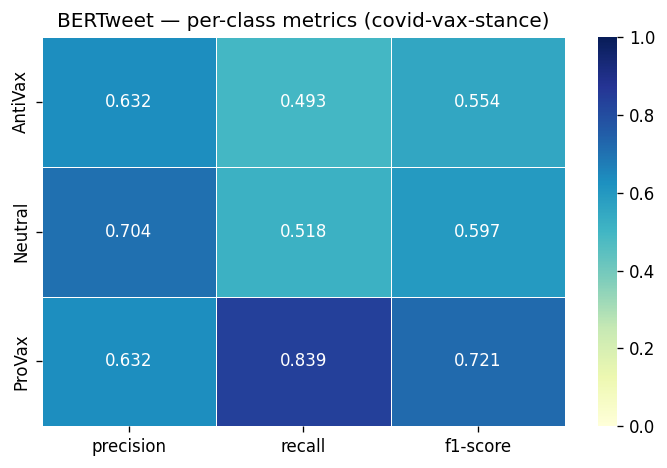

In [ ]:
preds = pd.read_csv(cvs_pred_path)
label_names = sorted(preds['label'].unique())
report = classification_report(preds['label'], preds['pred_label'], labels=label_names, output_dict=True)
per_class = pd.DataFrame(report).T.loc[label_names, ['precision','recall','f1-score']]

fig, ax = plt.subplots(figsize=(6, len(label_names) + 1))
sns.heatmap(per_class.astype(float), annot=True, fmt='.3f', cmap='YlGnBu', linewidths=0.5, ax=ax, vmin=0, vmax=1)
ax.set_title('BERTweet — per-class metrics (covid-vax-stance)')
plt.tight_layout()
plt.savefig(f'{PROJECT}/plots/per_class_heatmap.png', bbox_inches='tight')
plt.show()

## Save final results table

In [ ]:
final = pd.concat([baseline, bertweet_df, bt_transfer_df], ignore_index=True)
final.to_csv(f'{PROJECT}/results/final_results.csv', index=False)
print(final.sort_values(['dataset','macro_f1'], ascending=[True,False]).to_string(index=False))

Saved final_results.csv to Drive.

                 dataset    model  macro_f1
CVS→TweetEval (transfer) BERTweet    0.2696
CVS→TweetEval (transfer)      SVM    0.2293
CVS→TweetEval (transfer)       LR    0.1820
        TweetEval-stance BERTweet    0.6615
        TweetEval-stance      SVM    0.5110
        TweetEval-stance       LR    0.3719
TweetEval→CVS (transfer) BERTweet    0.2970
TweetEval→CVS (transfer)      SVM    0.1929
TweetEval→CVS (transfer)       LR    0.1196
        covid-vax-stance BERTweet    0.6240
        covid-vax-stance      SVM    0.4931
        covid-vax-stance       LR    0.3955


## 8BERTweet learning curves
Val macro-F1 per epoch that shows training dynamics and best checkpoint selection.

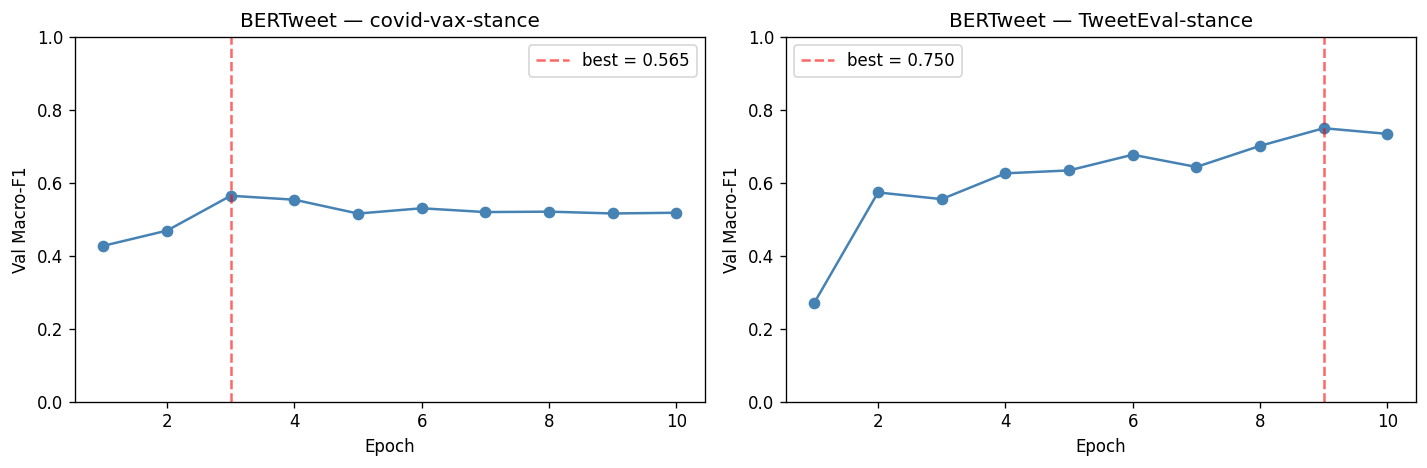

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, (code, name) in zip(axes, [('cvs', 'covid-vax-stance'), ('te', 'TweetEval-stance')]):
    log_path = f'{PROJECT}/results/bertweet_{code}_training_log.json'
    with open(log_path) as f:
        logs = json.load(f)
    eval_logs = [e for e in logs if 'eval_macro_f1' in e]
    epochs = [e['epoch'] for e in eval_logs]
    f1s = [e['eval_macro_f1'] for e in eval_logs]
    best = max(f1s)
    ax.plot(epochs, f1s, marker='o', color='steelblue')
    ax.axvline(epochs[f1s.index(best)], color='red', linestyle='--', alpha=0.6, label=f'best = {best:.3f}')
    ax.set_title(f'BERTweet - {name}')
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Val Macro-F1')
    ax.set_ylim(0, 1)
    ax.legend()

plt.tight_layout()
plt.savefig(f'{PROJECT}/plots/learning_curve.png', bbox_inches='tight')
plt.show()